# The Carbon Receipt


Inspired by the receipt format, a universally familiar format. This notebook visualizes the annual carbon "bill" of European aviation.

Each year is rendered as a stylized receipt showing:
Total flights and recovery vs 2019,
Total CO2 emitted,
CO2 per flight,
Average EU ETS carbon price,
Estimated carbon market cost


### Input files
airport_clean.csv  Monthly flight counts 
emission_network_clean.csv  Monthly CO₂ emissions 
carbon_price_monthly_cleaned.csv EU ETS carbon price 

### Output
carbon_receipt_6years.png,
carbon_receipt_2024.png

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
DATA_DIR = Path('../data/clean')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

# Palette
C_BLUE    = '#537D96'
C_RED     = '#BF4646'
C_INK     = '#1a2942'
C_GRAY    = '#9ca3af'
C_LIGHT   = '#f3f4f6'
C_WHITE   = '#ffffff'

## Load and aggregate data

In [20]:
# Load
airport = pd.read_csv(DATA_DIR / 'airport_clean.csv')
em      = pd.read_csv(DATA_DIR / 'emission_network_clean.csv')
carbon  = pd.read_csv(DATA_DIR / 'carbon_price_monthly_cleaned.csv')

# Monthly traffic
monthly_t = (
    airport
    .groupby(['YEAR', 'MONTH_NUM'])['FLT_TOT_1']
    .sum().reset_index()
    .rename(columns={'MONTH_NUM': 'month', 'FLT_TOT_1': 'flights', 'YEAR': 'year'})
)
baseline_2019 = monthly_t[monthly_t['year'] == 2019].set_index('month')['flights']
monthly_t['recovery'] = (monthly_t['flights'] / monthly_t['month'].map(baseline_2019) * 100).round(1)

# Monthly emissions
em_ecac = em[em['AREA'] == 'ECAC'].copy()
monthly_em = (
    em_ecac
    .groupby(['YEAR', 'MONTH'])
    .agg(co2_kg=('CO2_KG', 'sum'), nb=('NB_FLIGHTS', 'sum'))
    .reset_index()
    .rename(columns={'YEAR': 'year', 'MONTH': 'month'})
)
monthly_em['co2_mt'] = monthly_em['co2_kg'] / 1e9  # kg → Mt

# Annual aggregation
annual_t  = monthly_t[monthly_t['year'] <= 2024].groupby('year').agg(flights=('flights', 'sum')).reset_index()
annual_em = monthly_em.groupby('year').agg(co2_mt=('co2_mt', 'sum'), nb=('nb', 'sum')).reset_index()
annual_em['co2_pf'] = (annual_em['co2_mt'] * 1e6 / annual_em['nb']).round(3)  # t/flight
annual_eua = carbon.groupby('YEAR')['EUA_PRICE_EUR'].mean().reset_index().rename(columns={'YEAR': 'year', 'EUA_PRICE_EUR': 'avg_eua'})

# Merge
annual = annual_t.merge(annual_em, on='year').merge(annual_eua, on='year')
annual['co2_mt']     = annual['co2_mt'].round(2)
annual['cost_meur']  = (annual['co2_mt'] * 1e6 * annual['avg_eua'] / 1e6).round(1)
annual['recovery']   = (annual['flights'] / annual.loc[annual['year']==2019, 'flights'].values[0] * 100).round(1)

# Deltas vs 2019
ref = annual[annual['year'] == 2019].iloc[0]
annual['d_flights'] = ((annual['flights'] - ref['flights']) / ref['flights'] * 100).round(1)
annual['d_co2_mt']  = ((annual['co2_mt']  - ref['co2_mt'])  / ref['co2_mt']  * 100).round(1)
annual['d_co2_pf']  = ((annual['co2_pf']  - ref['co2_pf'])  / ref['co2_pf']  * 100).round(1)

print(annual[['year','flights','co2_mt','co2_pf','avg_eua','cost_meur','recovery','d_co2_pf']].to_string(index=False))

 year  flights  co2_mt  co2_pf   avg_eua  cost_meur  recovery  d_co2_pf
 2019 17185911  173.26   3.387 26.031667     4510.2     100.0       0.0
 2020  7417016   73.62   3.269 25.399167     1869.9      43.2      -3.5
 2021  9252593   96.87   3.273 53.675833     5199.6      53.8      -3.4
 2022 14356955  159.01   3.534 81.233333    12916.9      83.5       4.3
 2023 15764547  181.35   3.664 84.603333    15342.8      91.7       8.2
 2024 16613971  197.62   3.791 66.394167    13120.8      96.7      11.9


## Receipt drawing function

In [21]:
def draw_receipt(ax, row, ref_row, show_title=True):
    """
    Draw a single styled receipt on a matplotlib Axes.
    
    Parameters
    ----------
    ax      : matplotlib Axes
    row     : pd.Series — data for the year to display
    ref_row : pd.Series — 2019 baseline data
    """
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    year = int(row['year'])
    is_baseline = (year == 2019)
    
    # Background receipt paper
    receipt_bg = FancyBboxPatch(
        (0.04, 0.01), 0.92, 0.98,
        boxstyle='round,pad=0.01',
        facecolor=C_WHITE, edgecolor='#e5e7eb', linewidth=1.2,
        zorder=1
    )
    ax.add_patch(receipt_bg)

    # Color by CO2
    accent_col = C_GRAY if is_baseline else (C_RED if row['d_co2_mt'] > 0 else C_BLUE)
    top_bar = FancyBboxPatch(
        (0.04, 0.93), 0.92, 0.06,
        boxstyle='round,pad=0.01',
        facecolor=accent_col, edgecolor='none', zorder=2
    )
    ax.add_patch(top_bar)

    ax.text(0.5, 0.965, 'EUROPEAN AVIATION', ha='center', va='center',
            fontsize=5.5, color=C_WHITE, fontweight='bold',
            fontfamily='monospace', zorder=3)

    ax.text(0.5, 0.885, str(year), ha='center', va='center',
            fontsize=18, color=C_INK, fontweight='bold', fontfamily='monospace', zorder=3)

    ax.text(0.5, 0.845, 'CARBON RECEIPT', ha='center', va='center',
            fontsize=6, color=C_GRAY, fontfamily='monospace', zorder=3)

    def dashed_line(y):
        ax.plot([0.07, 0.93], [y, y], color='#d1d5db', lw=0.8,
                linestyle='--', dashes=(3, 3), zorder=2)

    dashed_line(0.825)

    def receipt_row(y, label, value, delta=None, bold=False, value_color=C_INK):
        fs_label = 6.5 if bold else 5.8
        fs_value = 6.5 if bold else 5.8
        fw = 'bold' if bold else 'normal'
        ax.text(0.09, y, label, ha='left', va='center',
                fontsize=fs_label, color=C_INK, fontfamily='monospace',
                fontweight=fw, zorder=3)
        ax.text(0.91, y, value, ha='right', va='center',
                fontsize=fs_value, color=value_color, fontfamily='monospace',
                fontweight=fw, zorder=3)
        if delta is not None and not is_baseline:
            sign  = '+' if delta > 0 else ''
            dcol  = C_RED if delta > 0 else C_BLUE
            ax.text(0.91, y - 0.038, f'{sign}{delta:.1f}% vs 2019',
                    ha='right', va='center',
                    fontsize=4.8, color=dcol, fontfamily='monospace', zorder=3)

    # Mini bar
    def mini_bar(y, pct, color, max_pct=130):
        """Draw a small filled bar 0–max_pct range."""
        bar_w = 0.84 * min(pct / max_pct, 1.0)
        ax.add_patch(patches.Rectangle(
            (0.08, y), 0.84, 0.016,
            facecolor='#f3f4f6', edgecolor='none', zorder=2
        ))
        ax.add_patch(patches.Rectangle(
            (0.08, y), bar_w, 0.016,
            facecolor=color, edgecolor='none', zorder=3, alpha=0.85
        ))

    # Flights
    y = 0.790
    rcol = C_GRAY if is_baseline else (C_BLUE if row['recovery'] >= 100 else C_RED)
    receipt_row(y, 'Total flights',
                f"{row['flights']/1e6:.2f}M",
                delta=row['d_flights'] if not is_baseline else None,
                bold=True, value_color=rcol)
    mini_bar(y - 0.058, row['recovery'], rcol)
    ax.text(0.09, y - 0.048, f"{row['recovery']:.0f}% of 2019",
            fontsize=4.5, color=C_GRAY, fontfamily='monospace', zorder=3)

    dashed_line(0.700)

    # CO2 total
    y = 0.672
    co2col = C_GRAY if is_baseline else (C_RED if row['d_co2_mt'] > 0 else C_BLUE)
    receipt_row(y, 'CO2 emitted',
                f"{row['co2_mt']:.2f} Mt",
                delta=row['d_co2_mt'], bold=True, value_color=co2col)
    max_co2 = 200
    mini_bar(y - 0.058, row['co2_mt'] / max_co2 * 100, co2col)
    ax.text(0.09, y - 0.048,
            f"{row['co2_mt']:.1f} megatonnes CO\u2082",
            fontsize=4.5, color=C_GRAY, fontfamily='monospace', zorder=3)

    dashed_line(0.578)

    # CO2 per flight
    y = 0.552
    pfcol = C_GRAY if is_baseline else (C_RED if row['d_co2_pf'] > 0 else C_BLUE)
    receipt_row(y, 'CO2 per flight',
                f"{row['co2_pf']:.3f} t",
                delta=row['d_co2_pf'], bold=False, value_color=pfcol)

    dashed_line(0.478)

    # Carbon price & cost
    y = 0.452
    receipt_row(y, 'Avg ETS price', f"\u20ac{row['avg_eua']:.0f}/tCO\u2082",
                bold=False, value_color=C_INK)

    # Double line separator = total
    ax.plot([0.07, 0.93], [0.380, 0.380], color=C_INK, lw=0.8, zorder=2)
    ax.plot([0.07, 0.93], [0.370, 0.370], color=C_INK, lw=0.8, zorder=2)

    y = 0.335
    receipt_row(y, 'Carbon market cost',
                f"\u20ac{row['cost_meur']:,.0f}M",
                bold=True, value_color=C_INK)

    dashed_line(0.270)
    if is_baseline:
        msg = '2019 BASELINE'
        mcol = C_GRAY
    elif year == 2020:
        msg = 'COVID: -57% flights'
        mcol = C_RED
    elif row['co2_mt'] > ref_row['co2_mt']:
        msg = f'MORE CO2 than 2019'
        mcol = C_RED
    elif row['recovery'] >= 90:
        msg = 'Almost recovered'
        mcol = C_BLUE
    else:
        msg = f"Recovery: {row['recovery']:.0f}%"
        mcol = C_GRAY

    ax.text(0.5, 0.225, msg, ha='center', va='center',
            fontsize=6.2, color=mcol, fontfamily='monospace',
            fontweight='bold', zorder=3)

    # Barcode
    np.random.seed(year)
    x_start = 0.15
    for _ in range(38):
        bw = np.random.choice([0.008, 0.014, 0.006])
        ax.add_patch(patches.Rectangle(
            (x_start, 0.06), bw, 0.10,
            facecolor=C_INK, edgecolor='none', alpha=0.85, zorder=3
        ))
        x_start += bw + np.random.uniform(0.003, 0.009)
        if x_start > 0.85: break

    ax.text(0.5, 0.035, f'ECAC-EUROCONTROL-{year}',
            ha='center', va='center',
            fontsize=4.5, color=C_GRAY, fontfamily='monospace', zorder=3)


## Six receipts (one per year)

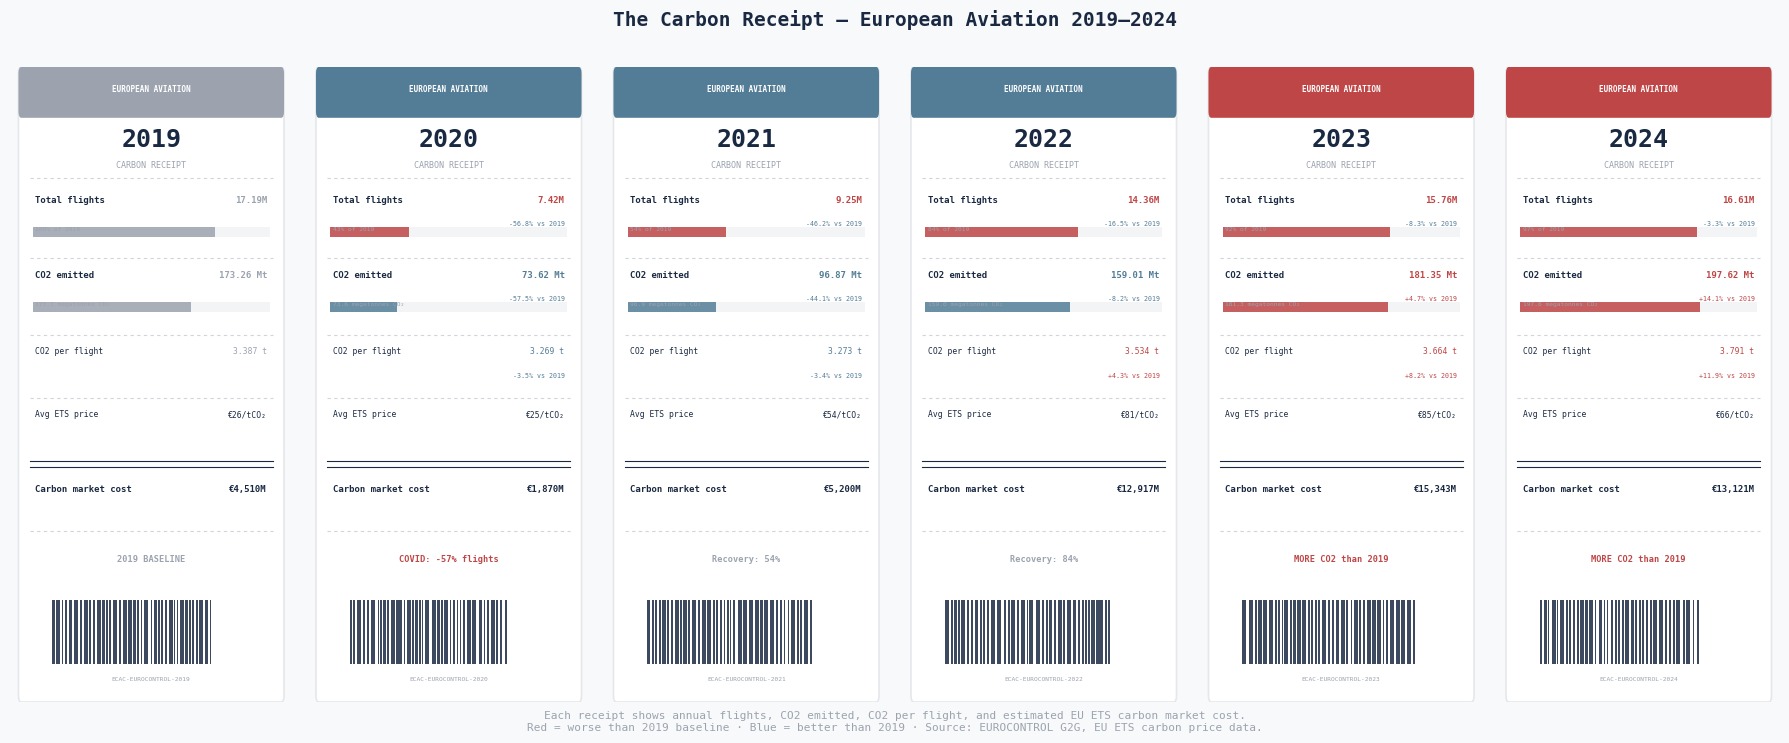

In [22]:
ref_row = annual[annual['year'] == 2019].iloc[0]

fig, axes = plt.subplots(1, 6, figsize=(18, 7))
fig.patch.set_facecolor('#f8f9fa')
for ax, (_, row) in zip(axes, annual.iterrows()):
    draw_receipt(ax, row, ref_row)
fig.suptitle(
    'The Carbon Receipt — European Aviation 2019–2024',
    fontsize=14, fontweight='bold', color=C_INK, y=1.01, fontfamily='monospace'
)
fig.text(
    0.5, -0.02,
    'Each receipt shows annual flights, CO2 emitted, CO2 per flight, and estimated EU ETS carbon market cost.\n'
    'Red = worse than 2019 baseline · Blue = better than 2019 · Source: EUROCONTROL G2G, EU ETS carbon price data.',
    ha='center', fontsize=8, color=C_GRAY, fontfamily='monospace'
)
plt.tight_layout()
path_6 = FIG_DIR / 'carbon_receipt_6years.png'
fig.savefig(path_6, dpi=180, bbox_inches='tight', facecolor='#f8f9fa')

## Single receipt 2024

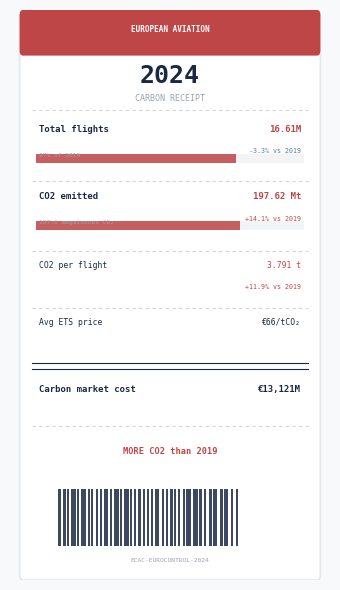

In [23]:
row_2024 = annual[annual['year'] == 2024].iloc[0]
fig2, ax2 = plt.subplots(1, 1, figsize=(3.5, 6))
fig2.patch.set_facecolor('#f8f9fa')
draw_receipt(ax2, row_2024, ref_row)
plt.tight_layout()
path_24 = FIG_DIR / 'carbon_receipt_2024.png'
fig2.savefig(path_24, dpi=200, bbox_inches='tight', facecolor='#f8f9fa')